# Cart-Pole RL Agent Training using Deep Reinforcement Learning

## Objective

Train an AI agent to balance a pole using Deep Q-Network (DQN) in OpenAI Gymnasium.

In [1]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

In [2]:
env = gym.make("CartPole-v1")

print(env.observation_space)
print(env.action_space)

Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Discrete(2)


In [3]:
model = DQN(
    "MlpPolicy",
    env,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [4]:
model.learn(total_timesteps=50000)

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 20.8     |
|    ep_rew_mean      | 20.8     |
|    exploration_rate | 0.984    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2674     |
|    time_elapsed     | 0        |
|    total_timesteps  | 83       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 20.9     |
|    ep_rew_mean      | 20.9     |
|    exploration_rate | 0.968    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 673      |
|    time_elapsed     | 0        |
|    total_timesteps  | 167      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.494    |
|    n_updates        | 16       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean    

In [5]:
mean_reward, std_reward = evaluate_policy(
    model,
    env,
    n_eval_episodes=10
)

print("Mean Reward:", mean_reward)
print("Standard Deviation:", std_reward)

c:\Users\Dell2\OneDrive\Documents\Deep-Learning-Projects\.venv\Lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Mean Reward: 394.9
Standard Deviation: 87.0648608796913


In [6]:
obs, info = env.reset()

for _ in range(500):
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)

    if terminated or truncated:
        obs, info = env.reset()

In [7]:
model.save("cartpole_dqn")

In [8]:
loaded_model = DQN.load("cartpole_dqn")

mean_reward, std_reward = evaluate_policy(
    loaded_model,
    env,
    n_eval_episodes=10
)

print("Loaded Model Mean Reward:", mean_reward)

Loaded Model Mean Reward: 406.9


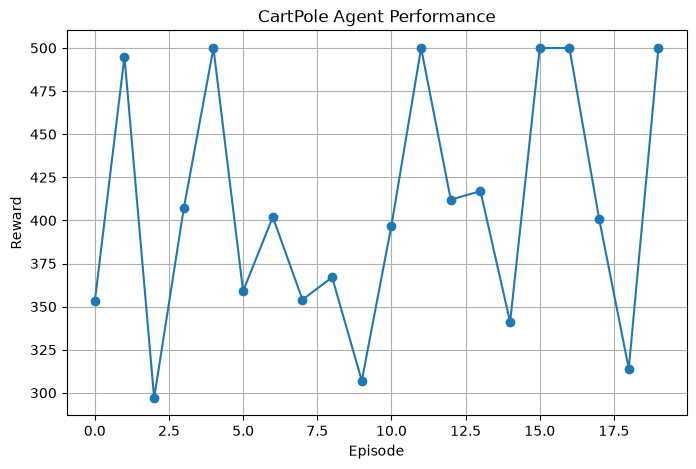

In [9]:
import matplotlib.pyplot as plt

episode_rewards = []

for _ in range(20):
    obs, info = env.reset()
    total_reward = 0

    while True:
        action, _ = model.predict(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    episode_rewards.append(total_reward)

plt.figure(figsize=(8,5))
plt.plot(episode_rewards, marker="o")
plt.title("CartPole Agent Performance")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

## Conclusion

- Created the CartPole-v1 environment using Gymnasium.
- Trained a Deep Q-Network (DQN) agent.
- Evaluated the trained agent using multiple episodes.
- Saved the trained model for future use.